In [45]:
#!pip install sentence-transformers

What subset of transformers models would be best to try?

How about a set of experiments with different number length too. So dataset1 includes numbers 0-10, dataset2 0-100, and so on.
Then, let's compare performance between number vs spell-out.
- I think it also had trouble with floats?


I'm thinking... in the pipeline of experiments... apart from different transformers, maybe distances to the embeddings can be tested? Like the method for each, like L2 and other distances ETC.

BERT-base-uncased collapses to 0 for everything except 30, which it guesses correctly.
BERT-base-cased collapses to 52 for everything.

# Cleaned notebook

In [46]:
import pathlib
from dataset_writing import *
from experiment import run_experiment
from plots import *
from models import SentenceEncoder
import pandas as pd

In [47]:
MODELS = {
    "MiniLM-L6": "all-MiniLM-L6-v2",
    "mpnet": "all-mpnet-base-v2",
    "BERT-nli-mean-tokens": "bert-base-nli-mean-tokens",
    "BERT-base-uncased": "bert-base-uncased",
    "BERT-base-cased": "bert-base-cased",
    "RoBERTa": "all-roberta-large-v1",
    "MiniLM-L12": "all-MiniLM-12-v2",
    "e5-small": "intfloat/e5-small",
    "unsup-simcse-bert": "princeton-nlp/unsup-simcse-bert-base-uncased",
    "MathBERT": "mathbert-base-uncased",
    "LLM2VEC": "McGill-NLP/LLM2Vec-Meta-Llama-3-8B-Instruct-mntp-supervised"
}

In [48]:
model_name = MODELS["BERT-nli-mean-tokens"]
#DATASET_FILE = pathlib.Path("../data/ages.txt")
AGE_RANGE = range(0, 100)
PCA_DIMS = 30
TSNE_PERPLEXITY = 30 # check the method to define the best perplexity.

In [49]:
encoder = SentenceEncoder(model_name)

In [50]:
age_format = "float"
#DATASET_FILE = pathlib.Path(f"../data/ages_{age_format}.txt")
DATASET_FILE = pathlib.Path(f"../data/cleaned_data.csv")
#out_dir = pathlib.Path(f"../results/{age_format}/{model_name}")
out_dir = pathlib.Path(f"../results/bigger_dataset/{model_name}")
out_dir.mkdir(parents=True, exist_ok=True)

In [51]:
#generate_sentences(DATASET_FILE, style=age_format) # already generated.

In [52]:
#sentences = load_sentences(path=DATASET_FILE)
sentences = load_bigger_dataset(path=DATASET_FILE)

Number of sentences: 16032
['the age is 65.0', 'the age is 57.0', 'the age is 51.0', 'the age is 55.0', 'the age is 33.0', 'the age is 36.0', 'the age is 32.0', 'the age is 19.0', 'the age is 62.0', 'the age is 39.0']


In [53]:
results = run_experiment(encoder, sentences, ages = AGE_RANGE)

In [54]:
df_points = pd.DataFrame({
    "age": list(AGE_RANGE),
    "true": results["true"],
    "pred": results["pred"],
    "error": results["errors"],
    "within_+-2": results["correct"],
    "full_error": results["full_error"],
})

safe_name = model_name.replace("/", "-")
csv_path = out_dir / f"{safe_name}_results.csv"
df_points.to_csv(csv_path, index=False)
print("Saved results to {}".format(csv_path))

Saved results to ..\results\bigger_dataset\bert-base-nli-mean-tokens\bert-base-nli-mean-tokens_results.csv


In [55]:
summary = pd.DataFrame([{
    "model": model_name,
    "accuracy": results["accuracy"],
    "exact_match_acc": results["exact_match_acc"]
}])

summary_path = out_dir / f"{safe_name}_summary.csv"
summary.to_csv(summary_path, index=False)

print("Summary saved to {}".format(summary_path))

Summary saved to ..\results\bigger_dataset\bert-base-nli-mean-tokens\bert-base-nli-mean-tokens_summary.csv


In [56]:
print(results["exact_match_acc"])

0.84


In [57]:
print(results["accuracy"])

0.86


In [58]:
# If you want to re-do the graphs without having to re-run the experiments.

"""df_points  = pd.read_csv(csv_path)

results = {
    "true":       df_points["true"].tolist(),
    "pred":       df_points["pred"].tolist(),
    "errors":     df_points["error"].tolist(),
    "correct":    df_points["within_+-2"].tolist(),
    "full_error": df_points["full_error"].tolist(),
    "exact_match_acc": df_points["exact_match_acc"].tolist()
}"""

'df_points  = pd.read_csv(csv_path)\n\nresults = {\n    "true":       df_points["true"].tolist(),\n    "pred":       df_points["pred"].tolist(),\n    "errors":     df_points["error"].tolist(),\n    "correct":    df_points["within_+-2"].tolist(),\n    "full_error": df_points["full_error"].tolist(),\n    "exact_match_acc": df_points["exact_match_acc"].tolist()\n}'

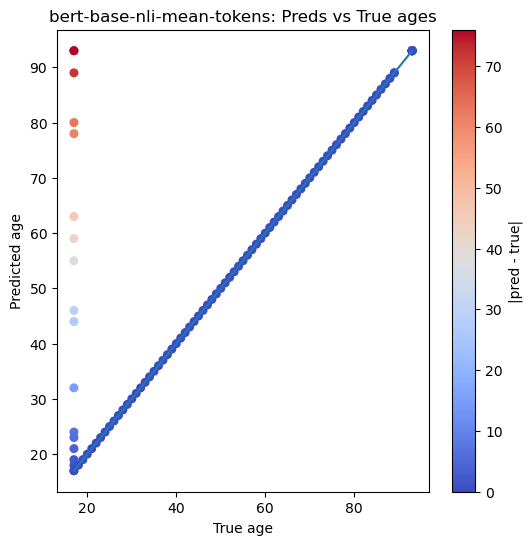

In [59]:
plot_concentration(safe_name, out_dir, results['true'], results['pred'], results['errors'])

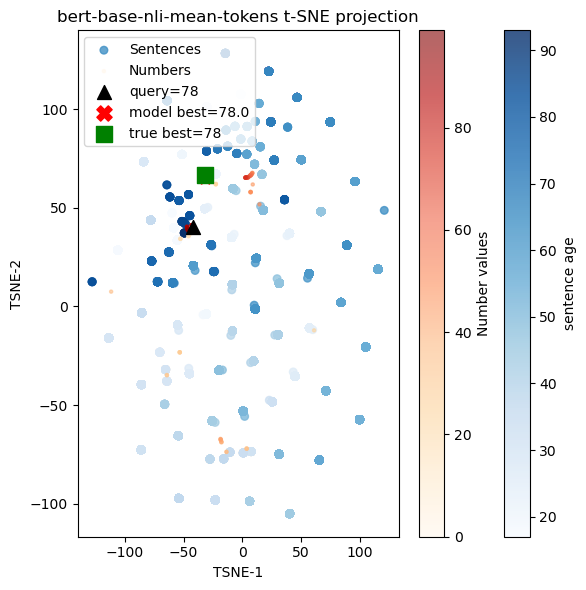

In [60]:
plot_tsne(safe_name, out_dir,
          78,
          sentences=sentences,
          encoder=encoder,
          pca_dims=PCA_DIMS,
          perp=5
          )

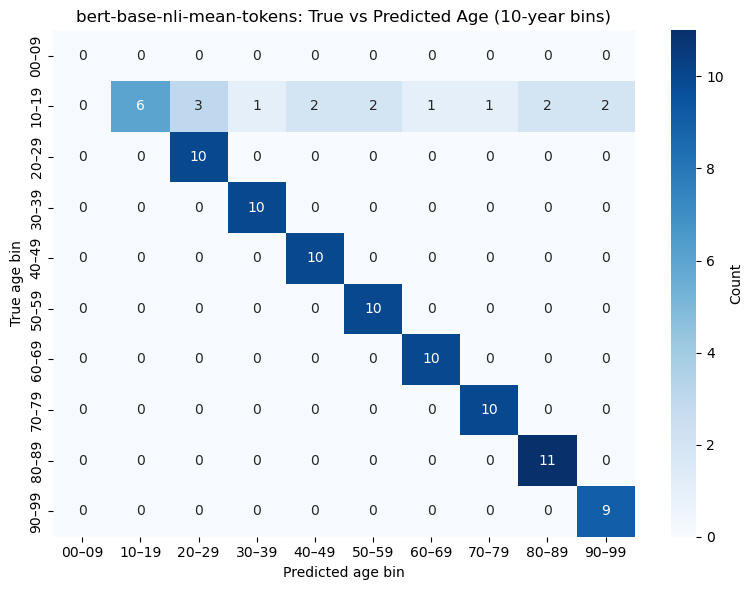

In [61]:
heatmap(results, safe_name, out_dir)

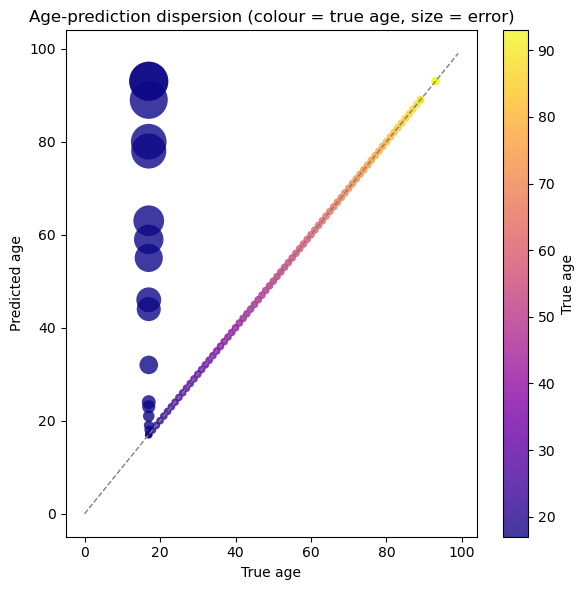

In [62]:
plot_concentration_color_gradient(results, safe_name, out_dir)

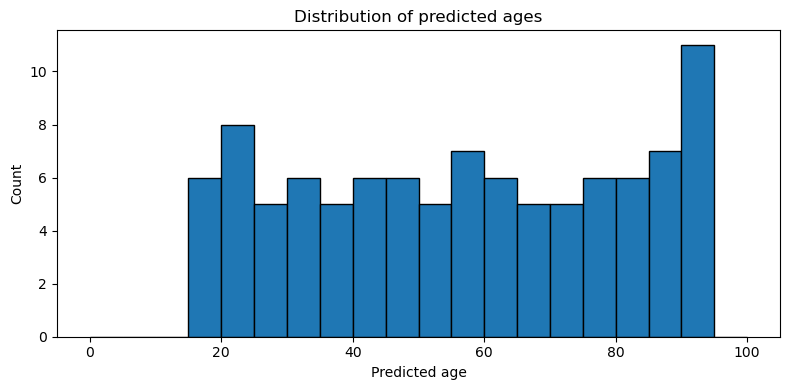

In [63]:
plot_prediction_histogram(results["pred"], bins=range(0,101,5), model_name=safe_name, out_folder=out_dir)

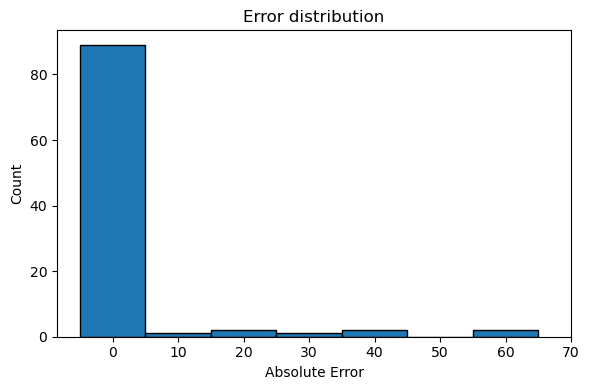

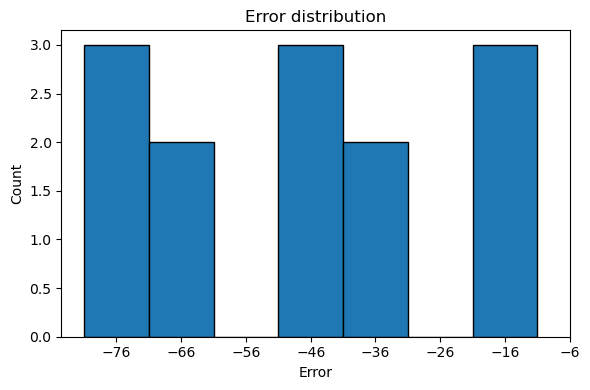

In [64]:
plot_error_histogram(results["errors"], safe_name, out_dir, absolute=True)
plot_error_histogram(results["full_error"], safe_name, out_dir, absolute=False)

Histogram is a great way to visualize error, but adding another one on top that is error instead of absolute error, to see if it tends to collapse upwards or downwards, maybe?

In [69]:
#DATASETS = {"digits", "float", "scientific", "words"}
DATASETS = {"bigger_dataset"}
results_summary(DATASETS, accuracy="accuracy")

| model                                        |   bigger_dataset |
|:---------------------------------------------|-----------------:|
| all-MiniLM-L6-v2                             |            0.890 |
| bert-base-nli-mean-tokens                    |            0.860 |
| intfloat/e5-small                            |            0.860 |
| princeton-nlp/unsup-simcse-bert-base-uncased |            0.800 |
